# 1. Data Loading

## Step 1: Data Loading + Field Extraction

In [8]:
import pandas as pd
import re

df = pd.read_csv('emails.csv')
df = df[['file', 'message']]
df.head()

,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


## Step 2: Extract fields from message

In [9]:
def extract_field(pattern, text):
    if not isinstance(text, str):
        return None
    
    match = re.search(pattern, text, re.IGNORECASE)
    return match.group(1).strip() if match else None

df['date'] = df['message'].apply(lambda x: extract_field(r"Date:\s*(.*?)(?:\n|$)", x))
df['from'] = df['message'].apply(lambda x: extract_field(r"From:\s*(.*?)(?:\n|$)", x))
df['to'] = df['message'].apply(lambda x: extract_field(r"To:\s*(.*?)(?:\n|$)", x))

## Step 3: Extract email body (actual content)

In [10]:
def extract_body(text):
    if not isinstance(text, str):
        return ""
        
    parts = re.split(r'\n\s*\n', text, maxsplit= 1)
    return parts[1].strip() if len(parts) > 1 else ""

df['body'] = df['message'].apply(extract_body)

## Step 4: Convert date → datetime

In [11]:
df['date'] = df['date'].str.replace(r"\(.*?\)", "", regex = True)

df['date'] = pd.to_datetime(
    df['date'], 
    errors= 'coerce',
    utc = True
)

C:\Users\TANMOY PAL\AppData\Local\Temp\ipykernel_25312\958664630.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(


In [12]:
df['date'].dtype

datetime64[ns, UTC]

In [13]:
df['year'] = df['date'].dt.year
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day_name()

,file,message,date,from,to,body,year,hour,day
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...,2001-05-14 23:39:00+00:00,phillip.allen@enron.com,tim.belden@enron.com,Here is our forecast,2001,23,Monday
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...,2001-05-04 20:51:00+00:00,phillip.allen@enron.com,john.lavorato@enron.com,Traveling to have a business meeting takes the...,2001,20,Friday
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...,2000-10-18 10:00:00+00:00,phillip.allen@enron.com,leah.arsdall@enron.com,test successful. way to go!!!,2000,10,Wednesday
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...,2000-10-23 13:13:00+00:00,phillip.allen@enron.com,randall.gay@enron.com,"Randy,\n\n Can you send me a schedule of the s...",2000,13,Monday
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...,2000-08-31 12:07:00+00:00,phillip.allen@enron.com,greg.piper@enron.com,Let's shoot for Tuesday at 11:45.,2000,12,Thursday
...,...,...,...,...,...,...,...,...,...
517396,zufferli-j/sent_items/95.,Message-ID: <26807948.1075842029936.JavaMail.e...,2001-11-28 21:30:11+00:00,john.zufferli@enron.com,kori.loibl@enron.com,This is a trade with OIL-SPEC-HEDGE-NG (John L...,2001,21,Wednesday
517397,zufferli-j/sent_items/96.,Message-ID: <25835861.1075842029959.JavaMail.e...,2001-11-28 20:47:48+00:00,john.zufferli@enron.com,john.lavorato@enron.com,Some of my position is with the Alberta Term b...,2001,20,Wednesday
517398,zufferli-j/sent_items/97.,Message-ID: <28979867.1075842029988.JavaMail.e...,2001-11-28 15:20:00+00:00,john.zufferli@enron.com,dawn.doucet@enron.com,2\n\n -----Original Message-----\nFrom: \tDouc...,2001,15,Wednesday
517399,zufferli-j/sent_items/98.,Message-ID: <22052556.1075842030013.JavaMail.e...,2001-11-27 19:52:45+00:00,john.zufferli@enron.com,jeanie.slone@enron.com,Analyst\t\t\t\t\tRank\n\nStephane Brodeur\t\t\...,2001,19,Tuesday


In [15]:
df_final = df

In [16]:
df_final.to_csv('emails_final.csv')

# 2. EDA (Understand before modeling)

In [17]:
df_final = pd.read_csv('emails_final.csv')

In [21]:
df_final = df_final.drop(columns=['Unnamed: 0'])

In [22]:
df_final

,file,message,date,from,to,body,year,hour,day
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...,2001-05-14 23:39:00+00:00,phillip.allen@enron.com,tim.belden@enron.com,Here is our forecast,2001,23,Monday
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...,2001-05-04 20:51:00+00:00,phillip.allen@enron.com,john.lavorato@enron.com,Traveling to have a business meeting takes the...,2001,20,Friday
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...,2000-10-18 10:00:00+00:00,phillip.allen@enron.com,leah.arsdall@enron.com,test successful. way to go!!!,2000,10,Wednesday
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...,2000-10-23 13:13:00+00:00,phillip.allen@enron.com,randall.gay@enron.com,"Randy,\n\n Can you send me a schedule of the s...",2000,13,Monday
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...,2000-08-31 12:07:00+00:00,phillip.allen@enron.com,greg.piper@enron.com,Let's shoot for Tuesday at 11:45.,2000,12,Thursday
...,...,...,...,...,...,...,...,...,...
517396,zufferli-j/sent_items/95.,Message-ID: <26807948.1075842029936.JavaMail.e...,2001-11-28 21:30:11+00:00,john.zufferli@enron.com,kori.loibl@enron.com,This is a trade with OIL-SPEC-HEDGE-NG (John L...,2001,21,Wednesday
517397,zufferli-j/sent_items/96.,Message-ID: <25835861.1075842029959.JavaMail.e...,2001-11-28 20:47:48+00:00,john.zufferli@enron.com,john.lavorato@enron.com,Some of my position is with the Alberta Term b...,2001,20,Wednesday
517398,zufferli-j/sent_items/97.,Message-ID: <28979867.1075842029988.JavaMail.e...,2001-11-28 15:20:00+00:00,john.zufferli@enron.com,dawn.doucet@enron.com,2\n\n -----Original Message-----\nFrom: \tDouc...,2001,15,Wednesday
517399,zufferli-j/sent_items/98.,Message-ID: <22052556.1075842030013.JavaMail.e...,2001-11-27 19:52:45+00:00,john.zufferli@enron.com,jeanie.slone@enron.com,Analyst\t\t\t\t\tRank\n\nStephane Brodeur\t\t\...,2001,19,Tuesday


## 1. Are there missing values in key fields?

👉 Why it matters: Missing from or date breaks temporal analysis

In [23]:
df_final.isnull().sum()

file       0
message    0
date       0
from       0
to         0
body       0
year       0
hour       0
day        0
dtype: int64

## 2. Are there duplicate emails?

👉 Enron dataset often has duplicates

In [24]:
df_final.duplicated().sum()

0

## 3. How many emails are sent over time? (Trend analysis)

👉 Detect spikes (important for anomaly detection)

In [27]:
df_final['date'] = pd.to_datetime(df_final['date'], errors= 'coerce', utc = True)

<Axes: xlabel='date'>

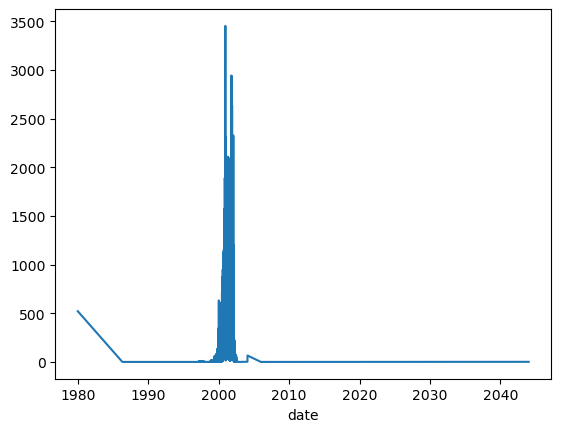

In [28]:
df_final.groupby(df_final['date'].dt.date).size().plot()

## 5. What is the distribution of email length?

In [29]:
df_final['email_length'] = df_final['body'].apply(len)

In [52]:
import matplotlib.pyplot as plt
import numpy as np

### 1. Log Transformation

Text(0.5, 1.0, 'Distribution of Email Length (Log Scale)')

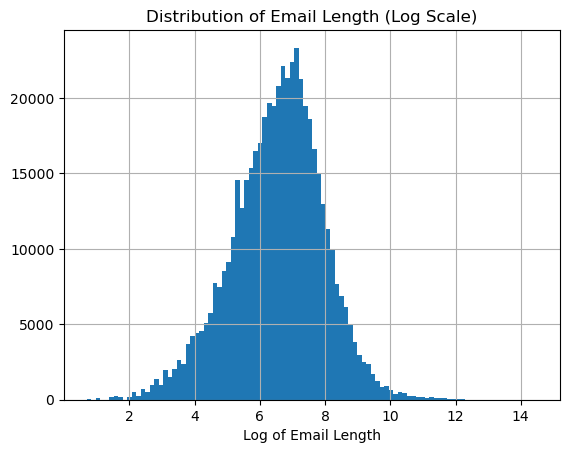

In [53]:
df_final['email_length'].apply(np.log1p).hist(bins = 100)
plt.xlabel('Log of Email Length')
plt.title('Distribution of Email Length (Log Scale)')

### 2. Clipping Outliers (Percentiles)

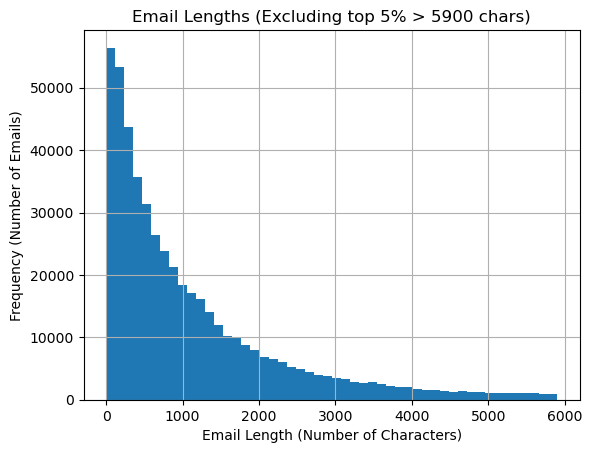

In [55]:
q = df_final['email_length'].quantile(0.95)

df_final[df_final['email_length'] < q]['email_length'].hist(bins = 50)

plt.title(f'Email Lengths (Excluding top 5% > {int(q)} chars)')
plt.xlabel('Email Length (Number of Characters)')
plt.ylabel('Frequency (Number of Emails)')

plt.show()

### 3. Boxplot Comparison

<Axes: xlabel='email_length'>

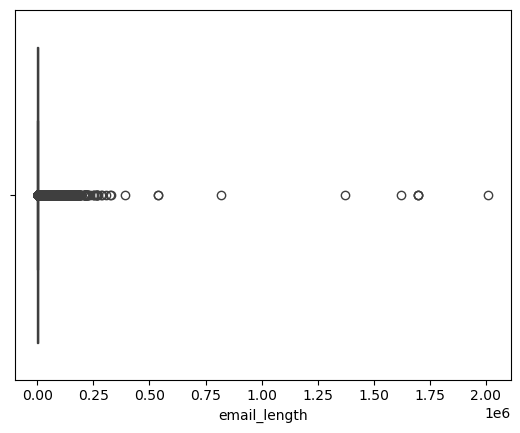

In [56]:
import seaborn as sns

sns.boxplot(x = df_final['email_length'])

## 6. Emails per user (sender activity)

In [57]:
df_final['from'].value_counts().head(10)

from
kay.mann@enron.com               16735
vince.kaminski@enron.com         14368
jeff.dasovich@enron.com          11411
pete.davis@enron.com              9149
chris.germany@enron.com           8801
sara.shackleton@enron.com         8777
enron.announcements@enron.com     8587
tana.jones@enron.com              8490
steven.kean@enron.com             6759
kate.symes@enron.com              5438
Name: count, dtype: int64

## 7. Emails per receiver

In [58]:
df_final['to'].value_counts().head(10)

to
pete.davis@enron.com         9155
X-cc:                        8652
tana.jones@enron.com         5677
sara.shackleton@enron.com    4974
vkaminski@aol.com            4870
jeff.dasovich@enron.com      4350
kate.symes@enron.com         3517
all.worldwide@enron.com      3324
mark.taylor@enron.com        3295
kay.mann@enron.com           3085
Name: count, dtype: int64

## 8. Emails by hour of the day

<Axes: xlabel='hour'>

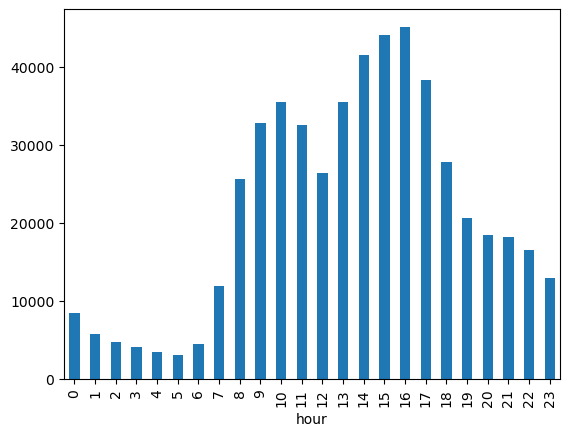

In [59]:
df_final['hour'].value_counts().sort_index().plot(kind = 'bar')

## 9. Emails by day of the week

<Axes: xlabel='day'>

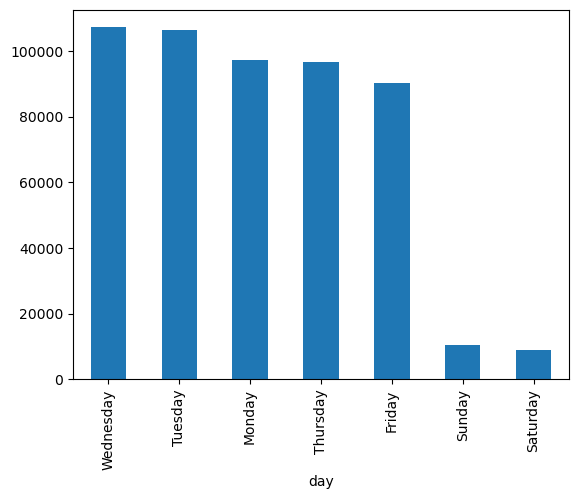

In [60]:
df_final['day'].value_counts().plot(kind = 'bar')

## 10. Who are the top sender–receiver pairs?

In [66]:
df_final.groupby(['from', 'to']).size().sort_values(ascending= False).head(10)

from                           to                                                                      
pete.davis@enron.com           pete.davis@enron.com                                                        9141
vince.kaminski@enron.com       vkaminski@aol.com                                                           4308
enron.announcements@enron.com  all.worldwide@enron.com                                                     2206
                               all.houston@enron.com                                                       1701
kay.mann@enron.com             suzanne.adams@enron.com                                                     1528
outlook.team@enron.com         X-cc:                                                                       1337
vince.kaminski@enron.com       shirley.crenshaw@enron.com                                                  1190
steven.kean@enron.com          maureen.mcvicker@enron.com                                                  1014


## 11. Keyword frequency (basic NLP insight)

In [67]:
from collections import Counter
import re

all_words = " ".join(df_final['body']).lower()
words = re.findall(r'\b\w+\b', all_words)

Counter(words).most_common(20)

[('the', 5657389),
 ('to', 4033024),
 ('and', 2564217),
 ('of', 2356547),
 ('a', 2060533),
 ('enron', 1746891),
 ('in', 1744731),
 ('for', 1444667),
 ('com', 1349779),
 ('20', 1253103),
 ('on', 1251361),
 ('is', 1219544),
 ('you', 1186343),
 ('i', 1162039),
 ('ect', 1141106),
 ('that', 1095322),
 ('s', 1093299),
 ('this', 903827),
 ('be', 845090),
 ('with', 762802)]

## 12. Emails sent outside working hours

In [68]:
late_emails = df_final[(df_final['hour'] < 6) | (df_final['hour'] > 22)]
len(late_emails)

42359

## 13. Emails per user over time (behavioral drift)

In [72]:
df_final.groupby(['from', df_final['date'].dt.date]).size().unstack(fill_value= 0)

date,1980-01-01,1986-04-26,1986-05-01,1997-01-01,1997-03-03,1997-03-05,1997-03-06,1997-03-07,1997-03-11,1997-03-16,...,2005-12-29,2007-02-11,2012-11-18,2012-11-28,2020-12-24,2020-12-29,2024-05-26,2043-12-28,2044-01-02,2044-01-04
from,,,,,,,,,,,,,,,,,,,,,
'todd'.delahoussaye@enron.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
--migrated--bmishkin@ercot.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
--migrated--dodle@ercot.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
-nikole@excite.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
-persson@ricemail.ricefinancial.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zufferli@enron.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
zulie.flores@enron.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
zvo2z17d0@untappedmarkets.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 14. Are there unusually long or short emails?

In [73]:
df_final[['email_length']].describe()

,email_length
count,5.174010e+05
mean,1.842764e+03
std,8.179131e+03
min,1.000000e+00
25%,2.870000e+02
50%,7.680000e+02
75%,1.753000e+03
max,2.011422e+06


## 15. Detect spikes in email activity (early anomaly signal)

In [76]:
daily_counts = df_final.groupby(df_final['date'].dt.date).size()

threshold = daily_counts.mean() + 2*daily_counts.std()
spikes = daily_counts[daily_counts > threshold]

print(spikes)

date
2000-11-06    1530
2000-11-07    1507
2000-11-09    1520
2000-11-10    1579
2000-11-13    1891
              ... 
2001-11-20    2329
2001-11-21    2210
2001-11-26    2430
2001-11-27    2637
2002-01-30    2327
Length: 76, dtype: int64


In [75]:
daily_counts

date
1980-01-01    522
1986-04-26      1
1986-05-01      1
1997-01-01      1
1997-03-03      3
             ... 
2020-12-29      1
2024-05-26      1
2043-12-28      1
2044-01-02      1
2044-01-04      2
Length: 1346, dtype: int64

# 3. Data Cleaning

In [1]:
import pandas as pd

In [2]:
df_final = pd.read_csv('emails_final.csv')

In [3]:
df_final = df_final.drop(columns= 'Unnamed: 0')

In [4]:
df_final

,file,message,date,from,to,body,year,hour,day
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...,2001-05-14 23:39:00+00:00,phillip.allen@enron.com,tim.belden@enron.com,Here is our forecast,2001,23,Monday
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...,2001-05-04 20:51:00+00:00,phillip.allen@enron.com,john.lavorato@enron.com,Traveling to have a business meeting takes the...,2001,20,Friday
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...,2000-10-18 10:00:00+00:00,phillip.allen@enron.com,leah.arsdall@enron.com,test successful. way to go!!!,2000,10,Wednesday
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...,2000-10-23 13:13:00+00:00,phillip.allen@enron.com,randall.gay@enron.com,"Randy,\n\n Can you send me a schedule of the s...",2000,13,Monday
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...,2000-08-31 12:07:00+00:00,phillip.allen@enron.com,greg.piper@enron.com,Let's shoot for Tuesday at 11:45.,2000,12,Thursday
...,...,...,...,...,...,...,...,...,...
517396,zufferli-j/sent_items/95.,Message-ID: <26807948.1075842029936.JavaMail.e...,2001-11-28 21:30:11+00:00,john.zufferli@enron.com,kori.loibl@enron.com,This is a trade with OIL-SPEC-HEDGE-NG (John L...,2001,21,Wednesday
517397,zufferli-j/sent_items/96.,Message-ID: <25835861.1075842029959.JavaMail.e...,2001-11-28 20:47:48+00:00,john.zufferli@enron.com,john.lavorato@enron.com,Some of my position is with the Alberta Term b...,2001,20,Wednesday
517398,zufferli-j/sent_items/97.,Message-ID: <28979867.1075842029988.JavaMail.e...,2001-11-28 15:20:00+00:00,john.zufferli@enron.com,dawn.doucet@enron.com,2\n\n -----Original Message-----\nFrom: \tDouc...,2001,15,Wednesday
517399,zufferli-j/sent_items/98.,Message-ID: <22052556.1075842030013.JavaMail.e...,2001-11-27 19:52:45+00:00,john.zufferli@enron.com,jeanie.slone@enron.com,Analyst\t\t\t\t\tRank\n\nStephane Brodeur\t\t\...,2001,19,Tuesday


## Step 1: Import libraries

In [5]:
import re
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to C:\Users\TANMOY
[nltk_data]     PAL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\TANMOY
[nltk_data]     PAL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Step 2: Initialize tools

In [6]:
stop_words = set(stopwords.words('english'))

stop_words.discard('not')
stop_words.discard('no')

lemmatizer = WordNetLemmatizer()

## Step 3: Define full cleaning function

In [7]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
        
    # 1. Remove forwarded / reply sections
    text = re.split(r"-----Original Message-----",text)[0]
    text = re.split(r"From:.*", text)[0]

    # 2. Remove signatures
    text = re.split(r"Regards,|Thanks,|Sincerely,|Best,", text)[0]

    # 3. Lowercase
    text = text.lower()

    # 4. Remove special characters
    text = re.sub(r'[^a-z\s]', ' ',text)

    # 5. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]

    # 7. Lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

## Step 4: Apply cleaning

In [8]:
df_final['clean_body'] = df_final['body'].apply(clean_text)

## Step 5: Remove empty rows

In [9]:
df_final = df_final[df_final['clean_body'].str.strip() != ""]

In [10]:
df_cleaned = df_final

In [11]:
df_cleaned.to_csv('email_cleaned.csv')

# 4. Feature Engineering

In [1]:
import pandas as pd

In [2]:
df_cleaned = pd.read_csv('email_cleaned.csv')

In [3]:
df_cleaned = df_cleaned.drop(columns= 'Unnamed: 0')

In [4]:
df_cleaned.head(2)

,file,message,date,from,to,body,year,hour,day,clean_body
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...,2001-05-14 23:39:00+00:00,phillip.allen@enron.com,tim.belden@enron.com,Here is our forecast,2001,23,Monday,forecast
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...,2001-05-04 20:51:00+00:00,phillip.allen@enron.com,john.lavorato@enron.com,Traveling to have a business meeting takes the...,2001,20,Friday,traveling business meeting take fun trip espec...


## A. Text Features — TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

tfidf = TfidfVectorizer(max_features= 3000, ngram_range= (1,2), min_df=5)
X_text = tfidf.fit_transform(df_cleaned['clean_body'])

svd = TruncatedSVD(n_components= 100, random_state= 42)
X_text_reduced = svd.fit_transform(X_text)

In [ ]:
X_text_reduced

### Step 1: Save everything

In [12]:
import joblib
import numpy as np

# Save models
joblib.dump(tfidf, 'tfidf.pkl')
joblib.dump(svd, 'svd.pkl')

# Save final features
np.save('X_text_reduced.npy', X_text_reduced)

### Step 2: Load everything later

In [13]:
import joblib
import numpy as np

# Load models
tfidf = joblib.load('tfidf.pkl')
svd = joblib.load('svd.pkl')

# Load features
X_text_reduced = np.load('X_text_reduced.npy')

## Optional Upgrade) BERT Embeddings

👉 Run this ONLY if you are NOT using TF-IDF above

In [5]:
df_cleaned.shape

(505411, 10)

In [6]:
import torch
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

# 1. Check if NVIDIA GPU (CUDA) is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"--- Currently using: {device.upper()} ---")

if device == 'cpu':
    print("Warning: GPU not detected. Ensure NVIDIA drivers and CUDA-enabled PyTorch are installed.")

--- Currently using: CUDA ---


In [ ]:
import torch
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

# 1. Check if NVIDIA GPU (CUDA) is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"--- Currently using: {device.upper()} ---")

if device == 'cpu':
    print("Warning: GPU not detected. Ensure NVIDIA drivers and CUDA-enabled PyTorch are installed.")

# 2. Load the model directly onto the GPU
model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# 3. Prepare your data
texts = df_cleaned['clean_body'].fillna("").tolist()

# 4. Increase batch size for GPU efficiency 
# (Set to 64 or 128 if you have 8GB+ VRAM; stick to 32 if you have 4GB VRAM)
batch_size = 32
embeddings = []

# Total batches
num_batches = (len(texts) + batch_size - 1) // batch_size

# 5. Run the encoding loop
for i in tqdm(range(0, len(texts), batch_size), desc="Encoding Batches"):
    batch = texts[i:i+batch_size]
    
    # encode() with convert_to_numpy handles the move from GPU memory to RAM for you
    batch_embeddings = model.encode(
        batch, 
        show_progress_bar=False, 
        convert_to_numpy=True,
        device=device
    )
    embeddings.append(batch_embeddings)

# 6. Combine all batches
X_text_bert = np.vstack(embeddings)

# 7. Save the result locally
np.save('X_text_bert.npy', X_text_bert)
print("Processing complete. File saved as 'X_text_bert.npy'.")

--- Currently using: CUDA ---


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Encoding Batches:   6%|▋         | 992/15795 [1:01:38<46:12:33, 11.24s/it]

### Save embeddings

In [ ]:
import numpy as np

np.save('X_text_bert.npy', X_text_bert)

### Load embeddings later

In [7]:
import numpy as np

# Load the file
# Note: mmap_mode='r' is great for huge files; it reads from disk without 
# flooding your RAM immediately.
X_text_bert = np.load('X_text_bert_v2.npy', mmap_mode='r')

print(f"Success! Loaded shape: {X_text_bert.shape}")
print(f"Data type: {X_text_bert.dtype}")

# To use it in a model (like Scikit-Learn), you might want to convert 
# a small chunk to float32 if the model requires it:
# first_ten_rows = X_text_bert[:10].astype('float32')

Success! Loaded shape: (505411, 384)
Data type: float16


## B. Behavioral Features

### 1. Email Length

In [5]:
df_cleaned['email_length'] = df_cleaned['body'].apply(len)

### 2. Word Count

In [6]:
df_cleaned['word_count'] = df_cleaned['clean_body'].apply(lambda x: len(x.split()))

### 3. Number of Recipients

In [7]:
import pandas as pd

df_cleaned['num_recipients'] = df_cleaned['to'].apply(lambda x: len(str(x).split(',')) 
                                                      if pd.notnull(x) else 0)

### 4. Keyword Flags

In [8]:
keywords = ['fraud', 'deal', 'transfer', 'money', 'confidential', 'urgent']

def keyword_flag(text):
    return int(any(word in text for word in keywords))
df_cleaned['keyword_flag'] = df_cleaned['clean_body'].apply(keyword_flag)

## C. Temporal Features

### 1. Hour (already exists, but ensure)

In [9]:
df_cleaned['date'] = pd.to_datetime(df_cleaned['date'], errors= 'coerce', utc = True)

In [10]:
df_cleaned['hour'] = df_cleaned['date'].dt.hour

### 2. Day of Week (numeric)

In [11]:
df_cleaned['day_num'] = df_cleaned['date'].dt.weekday

### 3. Rolling Email Frequency (per user)

In [12]:
df_cleaned['date'] = pd.to_datetime(df_cleaned['date'], errors= 'coerce', utc = True)

df_cleaned = df_cleaned.sort_values(['from', 'date']).reset_index(drop = True)
df_cleaned['temp_unique_id'] = df_cleaned.index

rolling_results = (
    df_cleaned.set_index('date')
    .groupby('from')['temp_unique_id']
    .rolling('3D')
    .count()
    .reset_index()
)

rolling_results = rolling_results.rename(columns = {'temp_unique_id' : 'email_count_rolling'})

df_cleaned['email_count_rolling'] = rolling_results['email_count_rolling'].values

df_cleaned = df_cleaned.drop(columns= ['temp_unique_id'])

print(df_cleaned[['date', 'from', 'email_count_rolling']].head())

                       date                           from  \
0 2001-10-24 13:50:26+00:00  'todd'.delahoussaye@enron.com   
1 2001-11-20 16:01:44+00:00  'todd'.delahoussaye@enron.com   
2 2001-11-20 16:01:44+00:00  'todd'.delahoussaye@enron.com   
3 2001-11-21 16:41:36+00:00  'todd'.delahoussaye@enron.com   
4 2001-11-21 16:41:36+00:00  'todd'.delahoussaye@enron.com   

   email_count_rolling  
0                  1.0  
1                  1.0  
2                  2.0  
3                  3.0  
4                  4.0  


In [13]:
df_engineered = df_cleaned

In [14]:
df_engineered.to_csv('email_engineered.csv')

# 5. Feature Combination

In [26]:
import pandas as pd

In [27]:
df_engineered = pd.read_csv('email_engineered.csv')

In [28]:
df_engineered = df_engineered.drop(columns= ['Unnamed: 0'])

In [29]:
df_engineered['date'] = pd.to_datetime(df_engineered['date'], errors= 'coerce', utc = True)

In [30]:
df_engineered.head(3)

,file,message,date,from,to,body,year,hour,day,clean_body,email_length,word_count,num_recipients,keyword_flag,day_num,email_count_rolling
0,scott-s/deleted_items/17.,Message-ID: <26593136.1075858914131.JavaMail.e...,2001-10-24 13:50:26+00:00,'todd'.delahoussaye@enron.com,"derek.bailey@enron.com, jean.bell@enron.com, r...","The below is a list of Monday, October 22 deal...",2001,13,Wednesday,list monday october deal confirmation not sent...,3252,343,4,1,2,1.0
1,love-p/deleted_items/440.,Message-ID: <18068955.1075862169423.JavaMail.e...,2001-11-20 16:01:44+00:00,'todd'.delahoussaye@enron.com,"derek.bailey@enron.com, jean.bell@enron.com, r...","The below is a list of Friday, November 16th d...",2001,16,Tuesday,list friday november th deal confirmation not ...,4294,475,4,1,1,1.0
2,mclaughlin-e/deleted_items/410.,Message-ID: <11140101.1075862643913.JavaMail.e...,2001-11-20 16:01:44+00:00,'todd'.delahoussaye@enron.com,"derek.bailey@enron.com, jean.bell@enron.com, r...","The below is a list of Friday, November 16th d...",2001,16,Tuesday,list friday november th deal confirmation not ...,4294,475,4,1,1,2.0


In [31]:
import numpy as np

# Load the file
# Note: mmap_mode='r' is great for huge files; it reads from disk without 
# flooding your RAM immediately.
X_text_bert = np.load('X_text_bert_v2.npy', mmap_mode='r')

print(f"Success! Loaded shape: {X_text_bert.shape}")
print(f"Data type: {X_text_bert.dtype}")

# To use it in a model (like Scikit-Learn), you might want to convert 
# a small chunk to float32 if the model requires it:
# first_ten_rows = X_text_bert[:10].astype('float32')

Success! Loaded shape: (505411, 384)
Data type: float16


In [32]:
X_text_bert

memmap([[-0.06964  , -0.01675  ,  0.02783  , ..., -0.03333  , -0.08575  ,
          0.01968  ],
        [ 0.06616  , -0.0001757, -0.00784  , ...,  0.02647  , -0.1067   ,
          0.02159  ],
        [ 0.0217   ,  0.03818  , -0.01982  , ..., -0.03354  ,  0.0312   ,
          0.0008297],
        ...,
        [-0.039    , -0.0276   , -0.010155 , ..., -0.1031   , -0.005512 ,
          0.05798  ],
        [-0.01779  , -0.03278  , -0.09845  , ..., -0.03427  ,  0.00394  ,
         -0.06155  ],
        [-0.03293  ,  0.0266   ,  0.02     , ...,  0.05356  , -0.04633  ,
          0.02417  ]], dtype=float16)

## Step 1: Select non-text features

In [33]:
feature_cols = [
    'email_length',
    'word_count',
    'num_recipients',
    'keyword_flag',
    'hour',
    'day_num',
    'email_count_rolling'
]

X_other = df_engineered[feature_cols].copy()

In [34]:
feature_cols = [
    'email_length',
    'word_count',
    'num_recipients',
    'keyword_flag',
    'hour',
    'day_num',
    'email_count_rolling'
]

import joblib

joblib.dump(feature_cols, 'feature_cols.pkl')

['feature_cols.pkl']

In [35]:
feature_cols = joblib.load('feature_cols.pkl')

## Step 2: Handle missing values

In [36]:
X_other = X_other.fillna(0)

## Step 3: Scale features

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_other_scaler = scaler.fit_transform(X_other)

In [38]:
import joblib

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [39]:
scaler = joblib.load('scaler.pkl')

## Step 4: Combine with text features

In [40]:
import numpy as np

X_final = np.hstack((X_text_bert, X_other_scaler))

In [41]:
X_final = X_final.astype('float32')

In [42]:
import numpy as np

np.save("X_final.npy", X_final)

In [43]:
X_final_loaded = np.load("X_final.npy")

print(X_final_loaded.shape)

(505411, 391)


# 6. Model (Core Step) & 7. Anomaly Detection Output

In [44]:
import numpy as np

In [45]:
X_final = np.load("X_final.npy")

print(X_final_loaded.shape)

(505411, 391)


## Step 1: Import model

In [46]:
from sklearn.ensemble import IsolationForest

## Step 2: Initialize model

In [47]:
model = IsolationForest(
    n_estimators= 200,
    contamination= 0.02,
    random_state= 42,
    n_jobs = -1
)

## Step 3: Fit model

In [48]:
model.fit(X_final)

IsolationForest(contamination=0.02, n_estimators=200, n_jobs=-1,
                random_state=42)

In [49]:
import joblib

joblib.dump(model, 'isolation_forest_model.pkl')

['isolation_forest_model.pkl']

In [50]:
import joblib

model = joblib.load('isolation_forest_model.pkl')

## Step 4: Predict anomalies

In [51]:
import pandas as pd

In [52]:
df_engineered = pd.read_csv('email_engineered.csv')

In [53]:
df_engineered = df_engineered.drop(columns= ['Unnamed: 0'])

In [54]:
df_engineered['anomaly_label'] = model.predict(X_final)

## Step 5: Get anomaly scores

In [55]:
df_engineered['anomaly_score'] = model.decision_function(X_final)

## Step 6: Quick check

In [56]:
df_engineered['anomaly_label'].value_counts()

anomaly_label
 1    495302
-1     10109
Name: count, dtype: int64

In [57]:
df_anomalies = df_engineered

In [58]:
df_anomalies.to_csv('email_anomaly.csv')

# 8. Post-Analysis

In [1]:
import pandas as pd

In [25]:
df_anomalies = pd.read_csv('email_anomaly.csv')

In [26]:
df_anomalies = df_anomalies.drop(columns= ['Unnamed: 0'])

In [27]:
df_anomalies['date'] = pd.to_datetime(df_anomalies['date'], errors= 'coerce', utc = True)

In [29]:
df_anomalies['anomaly_label'].unique()

array([ 1, -1], dtype=int64)

## Step 1: Filter only anomalies

In [30]:
df_anomalies_only = df_anomalies[df_anomalies['anomaly_label'] == -1].copy()

In [31]:
df_normal = df_anomalies[df_anomalies['anomaly_label'] == 1]

### 1. Top anomalous emails

👉 Lowest score = most suspicious

In [32]:
top_anomalies = df_anomalies_only.sort_values(by = 'anomaly_score').head(10)

In [33]:
top_anomalies[['date', 'from', 'to', 'anomaly_score', 'clean_body']]

,date,from,to,anomaly_score,clean_body
184548,2001-01-07 13:03:00+00:00,jeff.dasovich@enron.com,"dhunter@smithandkempton.com, eke@aelaw.com",-0.030118,greeting happy new year eve sub group met sinc...
365226,2002-01-28 13:37:29+00:00,pete.davis@enron.com,pete.davis@enron.com,-0.029732,start date hourahead hour no ancillary schedul...
15516,2001-05-21 08:40:00+00:00,ann.schmidt@enron.com,X-cc:,-0.029092,concern get saudi gas project role new york ti...
476124,2001-10-29 13:09:52+00:00,tom.rice@enron.com,"e..anderson@enron.com, raetta.zadow@enron.com,...",-0.028685,believe generated worth discretion midwest gas...
363494,2002-01-05 06:41:50+00:00,pete.davis@enron.com,pete.davis@enron.com,-0.027870,start date hourahead hour no ancillary schedul...
291403,2000-12-18 18:56:00+00:00,mark.haedicke@enron.com,"mark.taylor@enron.com, jeffrey.hodge@enron.com...",-0.027561,please review attached hypo give comment make ...
364224,2002-01-15 04:37:08+00:00,pete.davis@enron.com,pete.davis@enron.com,-0.027060,start date hourahead hour no ancillary schedul...
15261,2000-10-31 08:26:00+00:00,ann.schmidt@enron.com,"mark.palmer@enron.com, karen.denne@enron.com, ...",-0.026618,japan update enron say priority japan electric...
291269,2000-11-08 16:09:00+00:00,mark.haedicke@enron.com,michelle.cash@enron.com,-0.025814,look fine mark michelle cash sent twanda sweet...
365534,2002-02-01 18:37:10+00:00,pete.davis@enron.com,pete.davis@enron.com,-0.025634,start date hourahead hour no ancillary schedul...


### 2. Anomalies per user

👉 Who is most risky?

In [34]:
anomalies_per_user = (
    df_anomalies_only['from']
    .value_counts()
    .head(10)
)

print(anomalies_per_user)

from
pete.davis@enron.com             594
vince.kaminski@enron.com         318
enron.announcements@enron.com    175
jeff.dasovich@enron.com          172
mark.haedicke@enron.com          162
kay.mann@enron.com               129
steven.kean@enron.com            129
chris.germany@enron.com          121
mark.taylor@enron.com            104
liz.taylor@enron.com             103
Name: count, dtype: int64


### 3. Anomalies over time (spikes)
Daily trend:

<Axes: xlabel='date'>

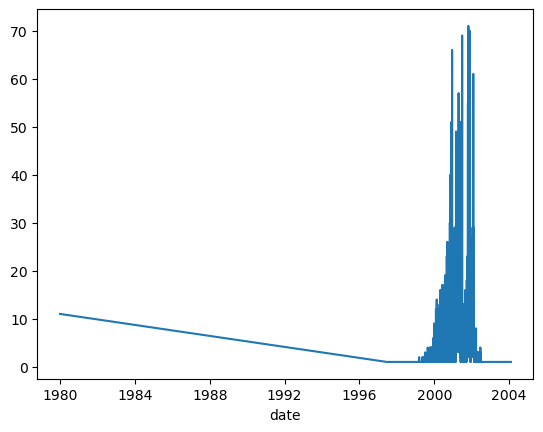

In [35]:
anomalies_over_time = (
    df_anomalies_only.groupby(df_anomalies['date'].dt.date)
    .size()
)

anomalies_over_time.plot()

### Detect spikes:

<Axes: xlabel='date'>

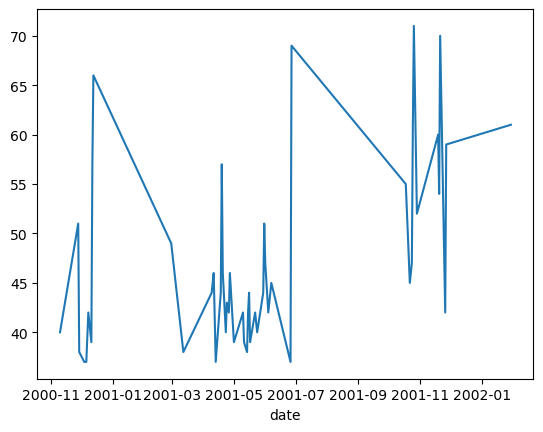

In [36]:
threshold = anomalies_over_time.mean() + 2*anomalies_over_time.std()

spikes = anomalies_over_time[anomalies_over_time > threshold]

spikes.plot()

### 4. % anomalies per user (better insight)

In [37]:
total_per_user = df_anomalies['from'].value_counts()
anomaly_per_user = df_anomalies_only['from'].value_counts()

In [38]:
user_risk_ratio = (anomaly_per_user/total_per_user).sort_values(ascending= False)
user_risk_ratio.head(10)

from
rcrq20011115@ombramarketing.com         1.0
fritzdave@aol.com                       1.0
pnarayan@andrew.cmu.edu                 1.0
ganesh.mani@enron.com                   1.0
pjarond@hotmail.com                     1.0
garobet@aol.com                         1.0
pinckney@centerbrook.com                1.0
phillip_morris.um.a.21.2096@em10.net    1.0
pbothwel@indiana.edu                    1.0
hagensick@tigfirstsource.com            1.0
Name: count, dtype: float64

## 5. Why anomalies? (basic explanation)

In [39]:
df_anomalies_only[['email_length', 'word_count', 'num_recipients',
              'keyword_flag', 'hour', 'email_count_rolling']].describe()

,email_length,word_count,num_recipients,keyword_flag,hour,email_count_rolling
count,10109.000000,10109.000000,10109.000000,10109.000000,10109.000000,10109.000000
mean,2647.595608,207.732417,1.722129,0.218024,13.532891,49.345633
std,8191.631727,748.320623,1.519770,0.412924,5.552269,117.704712
min,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000
25%,308.000000,18.000000,1.000000,0.000000,10.000000,3.000000
50%,829.000000,47.000000,1.000000,0.000000,14.000000,8.000000
75%,2019.000000,126.000000,2.000000,0.000000,17.000000,35.000000
max,262418.000000,15171.000000,62.000000,1.000000,23.000000,1308.000000


In [40]:
df_anomalies[df_anomalies['anomaly_label'] == 1][
    ['email_length', 'word_count', 'num_recipients',
     'keyword_flag', 'hour', 'email_count_rolling']
].describe()

,email_length,word_count,num_recipients,keyword_flag,hour,email_count_rolling
count,4.953020e+05,495302.000000,495302.000000,495302.000000,495302.000000,495302.000000
mean,1.822687e+03,123.940885,1.665816,0.160213,13.620918,38.776494
std,8.244918e+03,549.094785,1.960065,0.366804,5.022426,87.093573
min,2.000000e+00,1.000000,1.000000,0.000000,0.000000,1.000000
25%,2.850000e+02,14.000000,1.000000,0.000000,10.000000,3.000000
50%,7.610000e+02,38.000000,1.000000,0.000000,14.000000,9.000000
75%,1.740000e+03,102.000000,2.000000,0.000000,17.000000,36.000000
max,2.011422e+06,108742.000000,439.000000,1.000000,23.000000,1321.000000


# 9. Visualization (Streamlit)

In [3]:
df_engineered = pd.read_csv('email_engineered.csv')

In [6]:
df_engineered = df_engineered.drop(columns= ['Unnamed: 0'])

In [7]:
df_engineered.head(2)

,file,message,date,from,to,body,year,hour,day,clean_body,email_length,word_count,num_recipients,keyword_flag,day_num,email_count_rolling
0,scott-s/deleted_items/17.,Message-ID: <26593136.1075858914131.JavaMail.e...,2001-10-24 13:50:26+00:00,'todd'.delahoussaye@enron.com,"derek.bailey@enron.com, jean.bell@enron.com, r...","The below is a list of Monday, October 22 deal...",2001,13,Wednesday,list monday october deal confirmation not sent...,3252,343,4,1,2,1.0
1,love-p/deleted_items/440.,Message-ID: <18068955.1075862169423.JavaMail.e...,2001-11-20 16:01:44+00:00,'todd'.delahoussaye@enron.com,"derek.bailey@enron.com, jean.bell@enron.com, r...","The below is a list of Friday, November 16th d...",2001,16,Tuesday,list friday november th deal confirmation not ...,4294,475,4,1,1,1.0


In [8]:
df_anomaly = pd.read_csv('email_anomaly.csv')

In [10]:
df_anomaly = df_anomaly.drop(columns= ['Unnamed: 0'])

In [12]:
df_anomaly.head(2)

,file,message,date,from,to,body,year,hour,day,clean_body,email_length,word_count,num_recipients,keyword_flag,day_num,email_count_rolling,anomaly_label,anomaly_score
0,scott-s/deleted_items/17.,Message-ID: <26593136.1075858914131.JavaMail.e...,2001-10-24 13:50:26+00:00,'todd'.delahoussaye@enron.com,"derek.bailey@enron.com, jean.bell@enron.com, r...","The below is a list of Monday, October 22 deal...",2001,13,Wednesday,list monday october deal confirmation not sent...,3252,343,4,1,2,1.0,1,0.000623
1,love-p/deleted_items/440.,Message-ID: <18068955.1075862169423.JavaMail.e...,2001-11-20 16:01:44+00:00,'todd'.delahoussaye@enron.com,"derek.bailey@enron.com, jean.bell@enron.com, r...","The below is a list of Friday, November 16th d...",2001,16,Tuesday,list friday november th deal confirmation not ...,4294,475,4,1,1,1.0,1,0.009868


In [13]:
df_anomaly['anomaly_label'].unique()

array([ 1, -1], dtype=int64)

## Home Page

In [26]:
#================================Step 1: Load both datasets=======================================
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"E:\Desktop\GUVI\Project\Development of a Temporal-Aware NLP Pipeline\email_anomaly.csv")
df['date'] = pd.to_datetime(df['date'])

df_anomalies = df[df['anomaly_label'] == -1]

#==============================1. Timeline (email activity + anomalies)============================
st.subheader('📈 Email Activity vs Anomalies')

email_trend = df.groupby(df['date'].dt.date).size()
anomaly_trend = df_anomalies.groupby(df_anomalies['date'].dt.date).size()

fig, ax = plt.subplots()
email_trend.plot(ax = ax)
anomaly_trend.plot(ax=ax)

st.pyplot(fig)

#=============================2. Top Risky Users (ONLY anomalies)==================================
st.subheader('⚠️ Top Risky Users')
risky_users = df_anomalies['from'].value_counts().head(10)
st.bar_chart(risky_users)

#=============================3. Keyword Trends (from FULL dataset)================================
st.subheader("🔑 Keyword Trend")
keyword_trend = df.groupby(df['date'].dt.date)['keyword_flag'].sum()
st.line_chart(keyword_trend)

#===========================4. Flagged Emails Table (ONLY anomalies)============================
st.subheader("🚨 Flagged Emails")
st.dataframe(
    df_anomalies.sort_values(by = 'anomaly_score').head(50)
)

2026-04-28 00:30:25.553 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 00:30:25.558 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 00:30:25.563 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 00:30:26.174 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 00:30:26.526 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 00:30:26.528 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 00:30:26.533 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 00:30:26.535 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [19]:
cd 'E:\Desktop\GUVI\Project\Development of a Temporal-Aware NLP Pipeline\Streamlit'

streamlit run app.py

from
pete.davis@enron.com             594
vince.kaminski@enron.com         318
enron.announcements@enron.com    175
jeff.dasovich@enron.com          172
mark.haedicke@enron.com          162
                                ... 
james.barker@enron.com             1
jaime.williams@enron.com           1
jacqueline.didier@csfb.com         1
jacqueline.coleman@enron.com       1
zzmacmac@aol.com                   1
Name: count, Length: 2398, dtype: int64

## 2_🔍_Predict_Email.py

In [3]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from sentence_transformers import SentenceTransformer
import re

st.title("🔍 Email Anomaly Prediction")

#=====================================LOAD SAVED FILES=============================================
model = joblib.load("E:\Desktop\GUVI\Project\Development of a Temporal-Aware NLP Pipeline/isolation_forest_model.pkl")
scaler = joblib.load('E:\Desktop\GUVI\Project\Development of a Temporal-Aware NLP Pipeline/scaler.pkl')
feature_cols = joblib.load(r"E:\Desktop\GUVI\Project\Development of a Temporal-Aware NLP Pipeline\feature_cols.pkl")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

#========================================Input====================================================
st.subheader('Enter Email Details')

email_text = st.text_area('Email Content')

sender = st.text_input('Sender Email Address')
receivers = st.text_input('Receivers Email Address(comma separated)')
hour = st.slider('Hour of Email', 0, 23, 12)
day_num = st.selectbox('Day of Week (0=Mon)', list(range(7)))
email_count_rolling = st.number_input('Recent Email Count', value = 1)

#======================================Cleaning===================================================
def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    return text

#=================================Feature Engineering=============================================
if st.button('Predict'):

    clean_body = clean_text(email_text)

    # Text Features(Bert)
    X_text = bert_model.encode([clean_body])
    
    #Behavioral Features
    email_length = len(email_text)
    word_count = len(email_text.split())
    num_recipients = len(receivers.split(',')) if receivers else 0

    # simple keyword flag
    keywords = ['deal', 'money', 'transfer', 'urgent', 'confidential']
    keyword_flag = int(any(k in clean_body for k in keywords))

    # Create dataframe
    X_other = pd.DataFrame([[
        email_length,
        word_count,
        num_recipients,
        keyword_flag,
        hour,
        day_num,
        email_count_rolling
    ]], columns = feature_cols)

    #Scale
    X_other_scaled = scaler.transform(X_other)

    #Combine
    X_final = np.hstack((X_text, X_other_scaled))

    #Predict
    label = model.predict(X_final)[0]
    score = model.decision_function(X_final)[0]

    #================Output=====================
    st.subheader('Result')

    if label == -1:
        st.error(f'🚨 Anomalous Email (Score:{score:.4f})')
    else:
        st.success(f'✅ Normal Email ({score:.4f})')

<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
C:\Users\TANMOY PAL\AppData\Local\Temp\ipykernel_22076\130247694.py:11: SyntaxWarning: invalid escape sequence '\D'
  model = joblib.load("E:\Desktop\GUVI\Project\Development of a Temporal-Aware NLP Pipeline/isolation_forest_model.pkl")
C:\Users\TANMOY PAL\AppData\Local\Temp\ipykernel_22076\130247694.py:12: SyntaxWarning: invalid escape sequence '\D'
  scaler = joblib.load('E:\Desktop\GUVI\Project\Development of a Temporal-Aware NLP Pipeline/scaler.pkl')
C:\Users\TANMOY PAL\AppData\Local\Temp\ipykernel_22076\130247694.py:13: SyntaxWarning: invalid escape sequence '\D'
  feture_cols = joblib.load('E:\Desktop\GUVI\Project\Development of a Temporal-Aware NLP Pipeline/feature_cols.pkl')
20

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-28 21:29:22.143 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 21:29:22.147 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 21:29:22.151 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 21:29:22.157 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 21:29:22.161 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 21:29:22.164 Thread 'MainThread': missing 

In [4]:
feture_cols = joblib.load('E:\Desktop\GUVI\Project\Development of a Temporal-Aware NLP Pipeline/feature_cols.pkl')


<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\TANMOY PAL\AppData\Local\Temp\ipykernel_22076\1763208937.py:1: SyntaxWarning: invalid escape sequence '\D'
  feture_cols = joblib.load('E:\Desktop\GUVI\Project\Development of a Temporal-Aware NLP Pipeline/feature_cols.pkl')


In [5]:
feture_cols

['email_length',
 'word_count',
 'num_recipients',
 'keyword_flag',
 'hour',
 'day_num',
 'email_count_rolling']